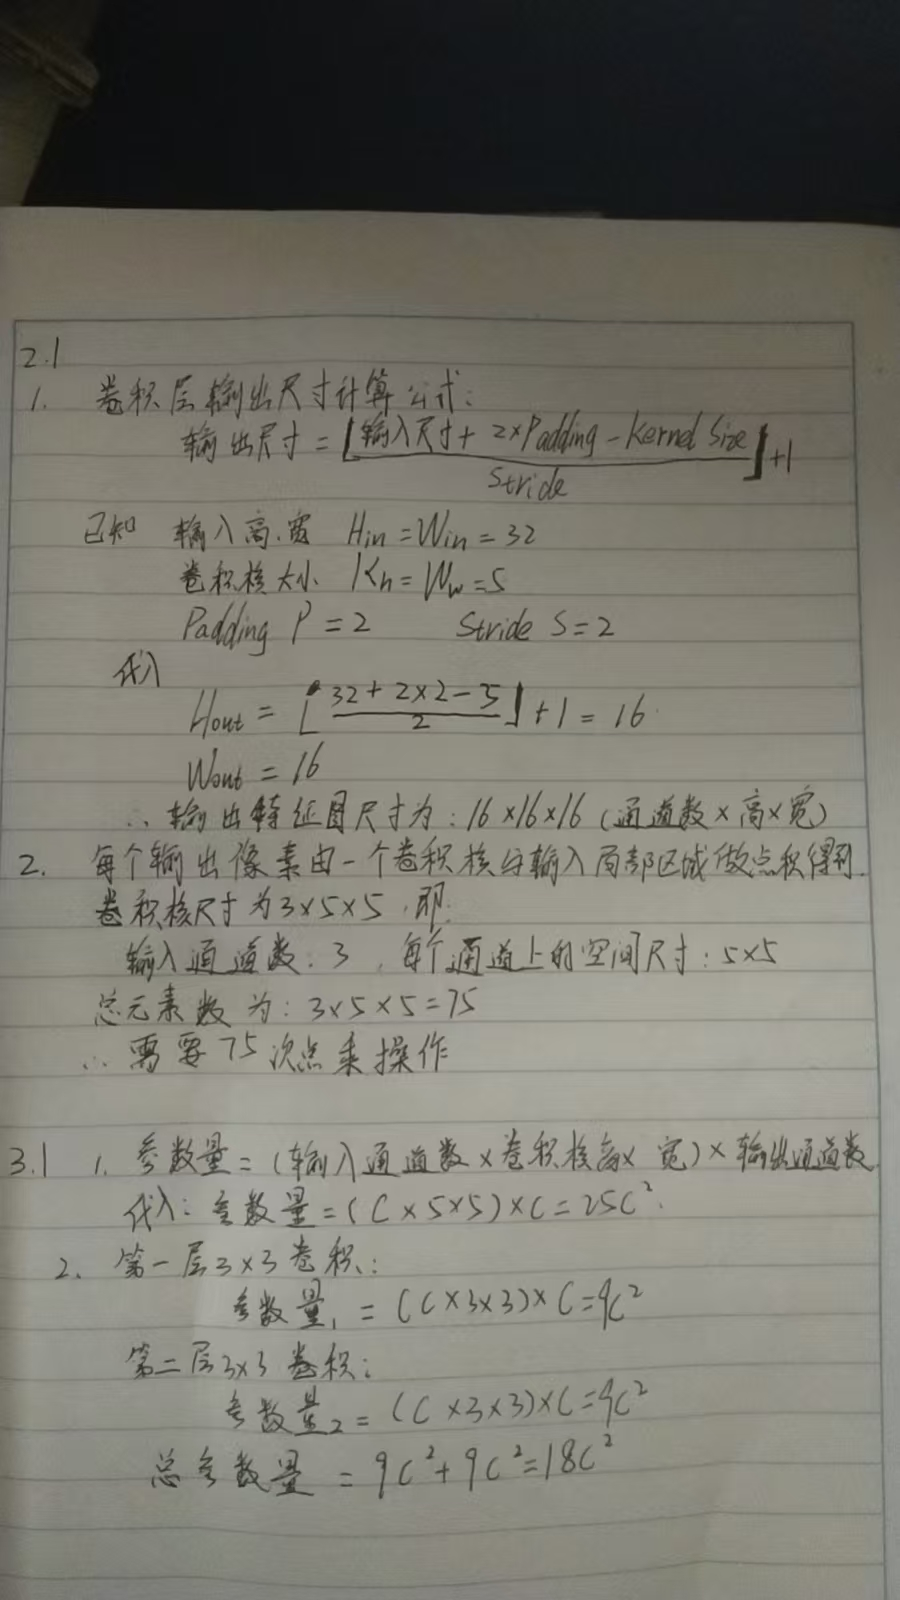

In [1]:
import numpy as np

def max_pool2d(input, kernel_size, stride=None, padding=0):
    """
    手动实现二维最大池化前向传播。

    参数:
        input: np.ndarray，形状为 (N, C, H, W)，N: batch_size, C: 通道数, H: 高, W: 宽。
        kernel_size: int 或 (int, int)，池化窗口大小。
        stride: int 或 (int, int)，步幅，若为 None 则默认等于 kernel_size。
        padding: int 或 (int, int)，填充大小，在每侧填充0。

    返回:
        output: np.ndarray，池化后的张量，形状为 (N, C, out_h, out_w)。
    """
    # 解析参数为元组形式 (h, w)
    if isinstance(kernel_size, int):
        k_h = k_w = kernel_size
    else:
        k_h, k_w = kernel_size

    if stride is None:
        stride_h = stride_w = k_h
    elif isinstance(stride, int):
        stride_h = stride_w = stride
    else:
        stride_h, stride_w = stride

    if isinstance(padding, int):
        pad_h = pad_w = padding
    else:
        pad_h, pad_w = padding

    # 输入维度
    N, C, H, W = input.shape

    # 填充后尺寸
    H_pad = H + 2 * pad_h
    W_pad = W + 2 * pad_w

    # 创建填充后的张量（在四周补0）
    padded = np.zeros((N, C, H_pad, W_pad), dtype=input.dtype)
    padded[:, :, pad_h:pad_h+H, pad_w:pad_w+W] = input

    # 计算输出尺寸
    out_h = (H_pad - k_h) // stride_h + 1
    out_w = (W_pad - k_w) // stride_w + 1
    # 确保输出尺寸为正
    assert out_h > 0 and out_w > 0, "池化窗口或步幅过大，导致输出尺寸非正"

    # 初始化输出张量
    output = np.zeros((N, C, out_h, out_w), dtype=input.dtype)

    # 遍历每个 batch、每个通道、每个输出位置
    for n in range(N):
        for c in range(C):
            for i in range(out_h):
                for j in range(out_w):
                    # 计算窗口在填充后张量中的起始位置
                    h_start = i * stride_h
                    w_start = j * stride_w
                    # 提取窗口区域
                    window = padded[n, c, h_start:h_start+k_h, w_start:w_start+k_w]
                    # 取最大值并赋值
                    output[n, c, i, j] = np.max(window)

    return output


# 简单测试示例（非必要，仅用于验证）
if __name__ == "__main__":
    # 创建一个随机输入 (batch=1, channel=1, height=4, width=4)
    x = np.array([[[[1, 2, 3, 4],
                    [5, 6, 7, 8],
                    [9, 10, 11, 12],
                    [13, 14, 15, 16]]]], dtype=np.float32)

    # 测试不同参数
    print("kernel=2, stride=2, padding=0:")
    out = max_pool2d(x, kernel_size=2, stride=2, padding=0)
    print(out)  # 应输出 [[[[6, 8], [14, 16]]]]

    print("\nkernel=2, stride=1, padding=1:")
    out = max_pool2d(x, kernel_size=2, stride=1, padding=1)
    # 输出应为 5x5 的池化结果（填充后 6x6，窗口 2x2，步幅1 -> 5x5）
    print(out.shape)
    print(out)

kernel=2, stride=2, padding=0:
[[[[ 6.  8.]
   [14. 16.]]]]

kernel=2, stride=1, padding=1:
(1, 1, 5, 5)
[[[[ 1.  2.  3.  4.  4.]
   [ 5.  6.  7.  8.  8.]
   [ 9. 10. 11. 12. 12.]
   [13. 14. 15. 16. 16.]
   [13. 14. 15. 16. 16.]]]]


In [3]:
import torch
import torch.nn as nn

# 定义 NiN 块（复制上面的函数）
def nin_block(in_channels, out_channels, kernel_size, stride, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU()
    )

# 实例化一个 NiN 块，例如输入通道3，输出通道64，3x3卷积，步幅1，填充1
block = nin_block(3, 64, 3, 1, 1)

# 打印网络结构（有输出）
print(block)

# 测试前向传播，查看输出形状（有输出）
x = torch.randn(1, 3, 32, 32)   #  batch=1, 通道3, 高宽32
out = block(x)
print(f"输入形状: {x.shape} -> 输出形状: {out.shape}")

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (3): ReLU()
  (4): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (5): ReLU()
)
输入形状: torch.Size([1, 3, 32, 32]) -> 输出形状: torch.Size([1, 64, 32, 32])


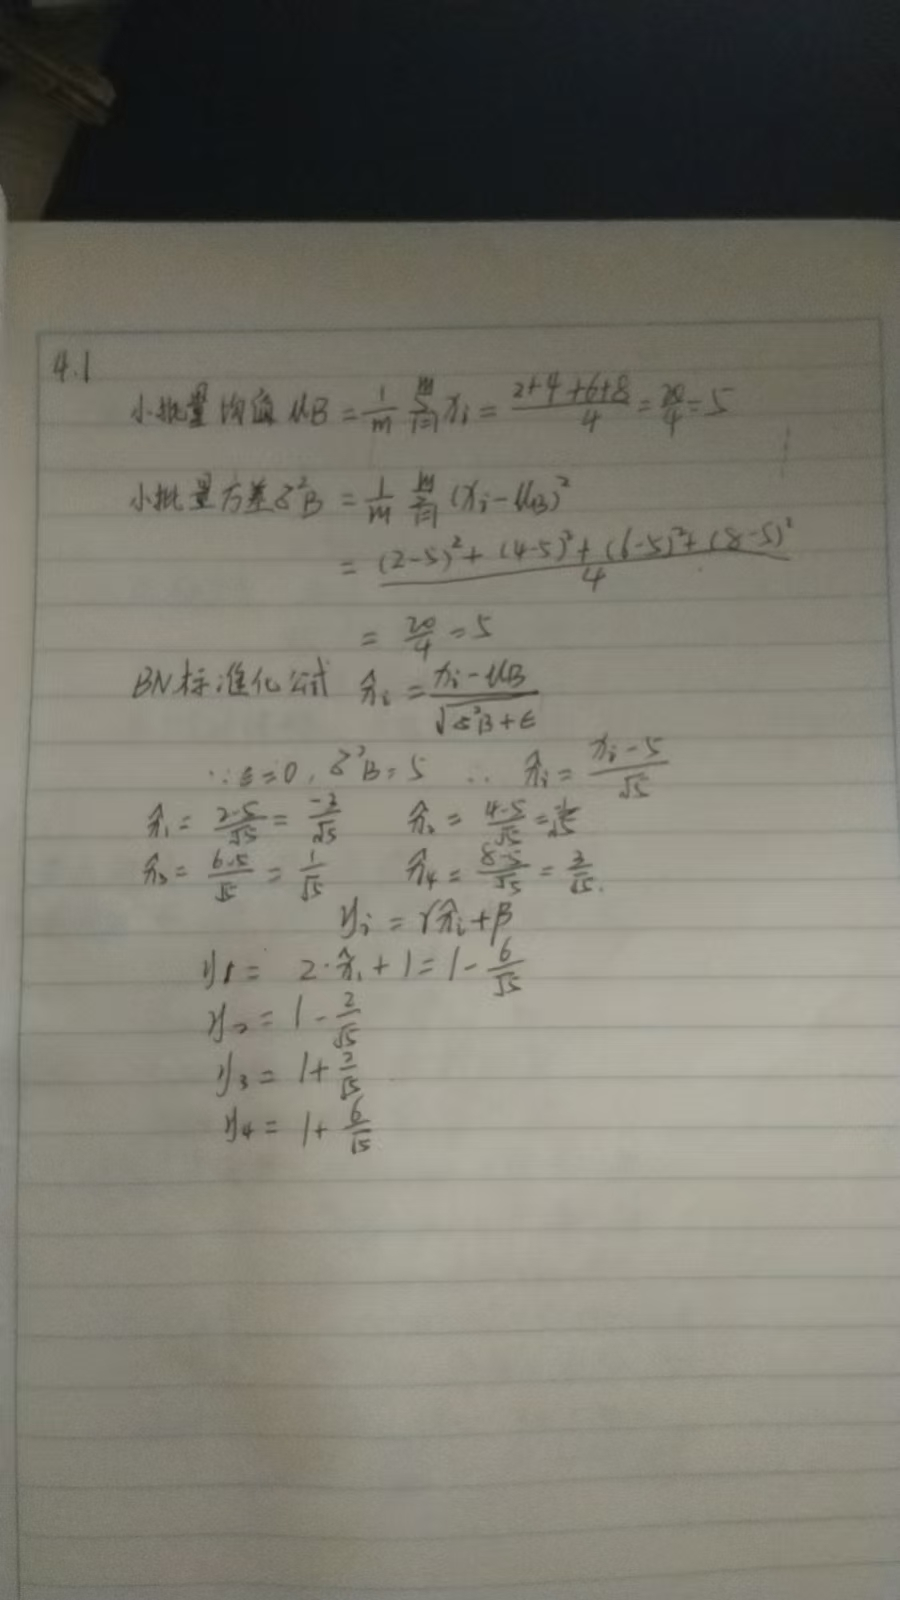

In [4]:
import torch
import torch.nn as nn

class Residual(nn.Module):
    """残差块，包含两个 3x3 卷积层和批量归一化，支持可选的 1x1 短路连接。"""
    
    def __init__(self, in_channels, out_channels, stride=1, use_1x1conv=False):
        """
        参数:
            in_channels (int): 输入通道数
            out_channels (int): 输出通道数
            stride (int): 第一个卷积层的步幅（第二个卷积层步幅固定为1）
            use_1x1conv (bool): 是否使用 1x1 卷积调整输入以匹配输出形状
        """
        super(Residual, self).__init__()
        
        # 第一个卷积层：可能改变空间尺寸（stride > 1）和通道数
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # 第二个卷积层：保持空间尺寸和通道数不变
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 可选的 1x1 短路连接：仅在 use_1x1conv=True 时用于调整输入
        if use_1x1conv:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                                      stride=stride, bias=False)
            self.bn_shortcut = nn.BatchNorm2d(out_channels)
        else:
            self.shortcut = None
        
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        # 主路径：conv1 -> bn1 -> relu -> conv2 -> bn2
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        
        # 短路连接
        if self.shortcut is not None:
            identity = self.shortcut(x)
            identity = self.bn_shortcut(identity)
        else:
            # 若没有 1x1 卷积，则直接使用输入（需要形状匹配，否则会报错）
            identity = x
        
        # 残差相加 + 最终激活
        out += identity
        out = self.relu(out)
        
        return out
# 测试：通道数变化 + 空间尺寸减半
block1 = Residual(3, 64, stride=2, use_1x1conv=True)
x = torch.randn(1, 3, 32, 32)
y = block1(x)
print(y.shape)  # torch.Size([1, 64, 16, 16])

# 测试：通道数不变，步幅为1，不使用1x1卷积
block2 = Residual(64, 64, stride=1, use_1x1conv=False)
x2 = torch.randn(1, 64, 16, 16)
y2 = block2(x2)
print(y2.shape)  # torch.Size([1, 64, 16, 16])

torch.Size([1, 64, 16, 16])
torch.Size([1, 64, 16, 16])


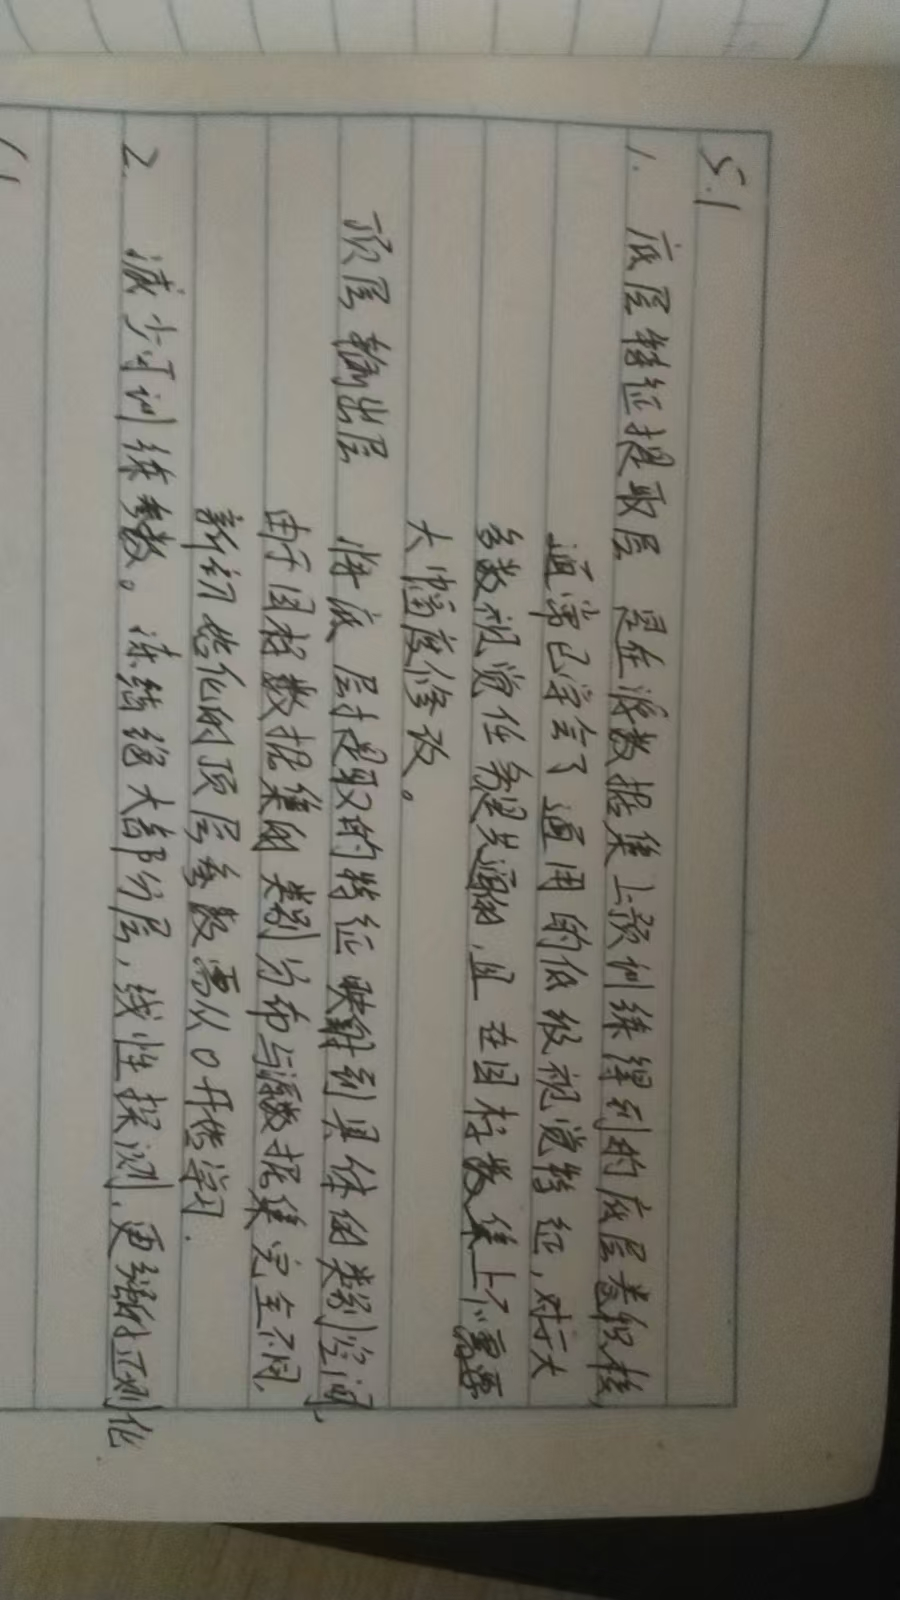

In [6]:
from torchvision import transforms
from PIL import Image
import torch

# 定义增广管道
augmentation_pipeline = transforms.Compose([
    transforms.RandomResizedCrop(size=224, scale=(0.08, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.ToTensor()
])

random_image = Image.new('RGB', (1000, 800), color='red')  # 创建一张纯色图像
augmented = augmentation_pipeline(random_image)
print(f"增广后张量形状: {augmented.shape}")  # 输出: torch.Size([3, 224, 224])


增广后张量形状: torch.Size([3, 224, 224])


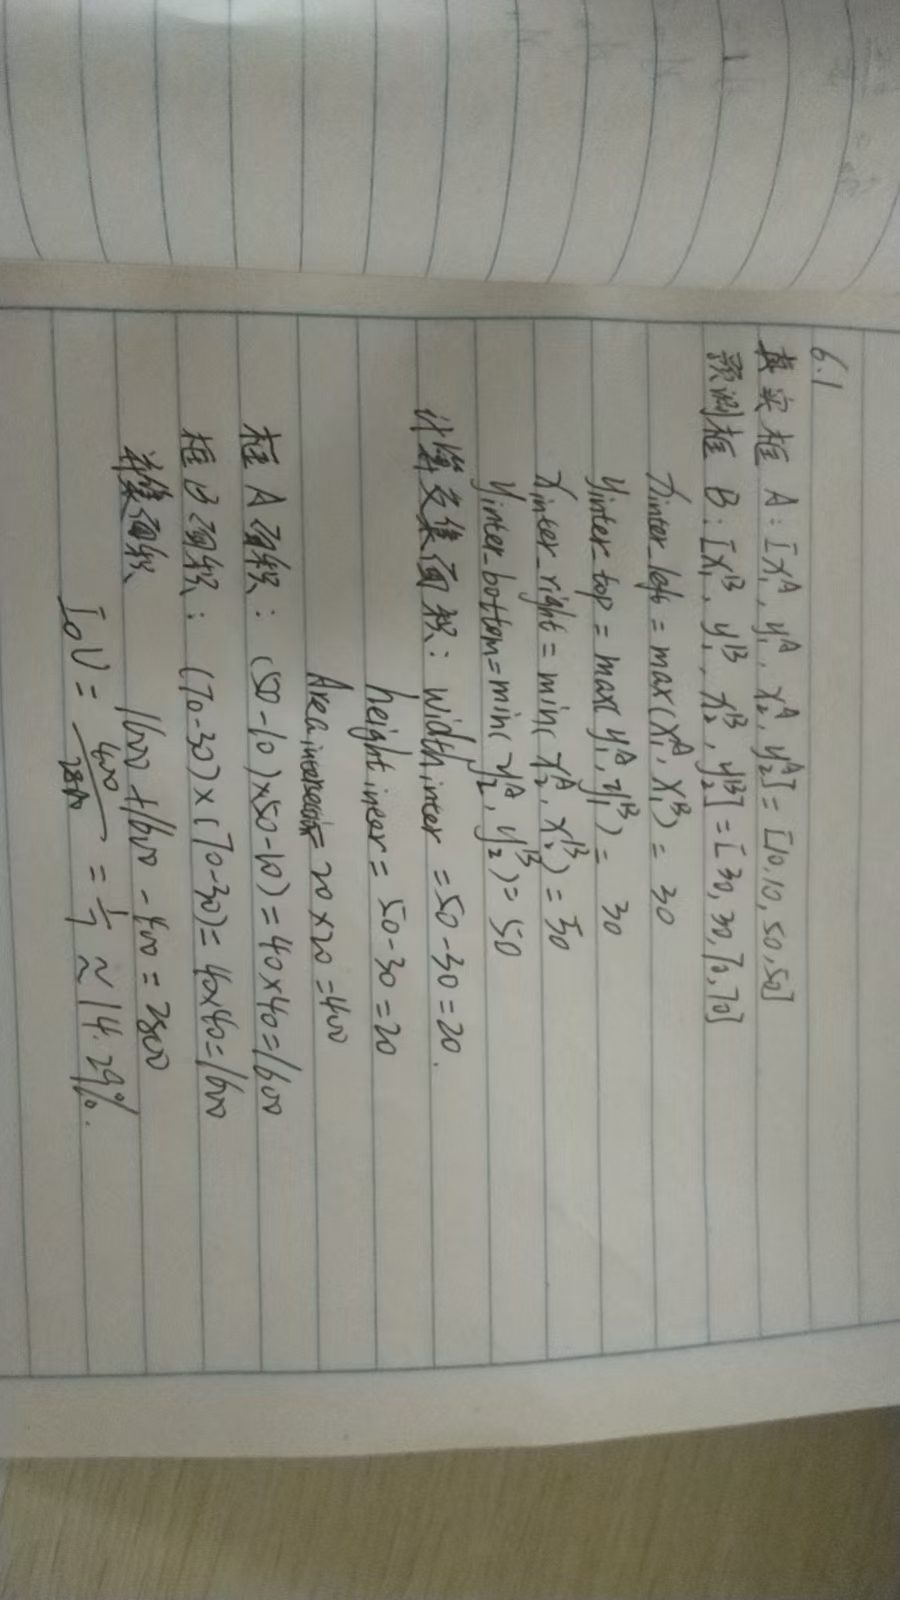

In [7]:
import torch
import torch.nn.functional as F

def label_smoothing_cross_entropy(logits, targets, epsilon=0.1):
    """
    计算标签平滑后的交叉熵损失。

    参数:
        logits: torch.Tensor，形状 (N, K)，模型输出的未归一化分数
        targets: torch.LongTensor，形状 (N,)，每个样本的真实类别索引 (0 ~ K-1)
        epsilon: float，平滑因子，默认 0.1

    返回:
        loss: torch.Tensor，标量，batch 平均损失
    """
    K = logits.size(-1)                     # 类别数
    # 计算 log_softmax（数值稳定）
    log_probs = F.log_softmax(logits, dim=-1)   # (N, K)

    # 构建平滑后的真实标签分布 q
    smooth_labels = torch.full_like(log_probs, epsilon / (K - 1))
    smooth_labels.scatter_(1, targets.unsqueeze(1), 1 - epsilon)

    # 交叉熵损失 = -Σ q_k log(p_k)
    loss = - (smooth_labels * log_probs).sum(dim=1).mean()
    return loss


# 简单测试示例
if __name__ == "__main__":
    # 假设 batch_size=2, 类别数 K=5
    logits = torch.randn(2, 5, requires_grad=True)
    targets = torch.tensor([1, 3])

    loss = label_smoothing_cross_entropy(logits, targets, epsilon=0.1)
    print(f"损失值: {loss.item()}")

    # 验证梯度是否可正常回传
    loss.backward()
    print("梯度计算完成，无报错。")

损失值: 2.040189266204834
梯度计算完成，无报错。
